In [120]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import scipy

In [121]:
def init_dataset():
    iris_dataset=load_iris()
    D=iris_dataset.data.T
    L=iris_dataset.target
    classes=iris_dataset.target_names
    features=iris_dataset.feature_names
    
    print(f"Le classi sono : {classes} e le features :{features}")
    
    return D,L,classes,features

D,L,classes,features=init_dataset()

Le classi sono : ['setosa' 'versicolor' 'virginica'] e le features :['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [122]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=getCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]

mu=getMu(D)
C=getC(D)
print(f"La media è {mu} e la matrice di Covarianza è: {C}")

La media è [5.84333333 3.05733333 3.758      1.19933333] e la matrice di Covarianza è: [[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


In [123]:
def get_hist(D,L,features,classes):
    n_features = D.shape[0]
    for i in range(n_features):
        plt.figure()
        plt.xlabel(f"{features[i]}")
        plt.ylabel("Density")
        for c in range(len(classes)):
            mask= L==c
            D0=D[:,mask][i,:]
            plt.hist(D0,bins=5,density=True,alpha=0.5,label=classes[c])
        
        
        plt.legend()
        plt.show()

def get_scatters(D,L,features,classes):
    n_features = D.shape[0]
    for i in range(n_features):
        for j in range(i+1,n_features):
            plt.figure()
            plt.xlabel(f"{features[i]}")
            plt.ylabel(f"{features[j]}")
            for c in range(len(classes)):
                mask=L==c
                D0=D[:,mask]
                plt.scatter(D0[i,:],D0[j,:],label=classes[c])
            
            plt.legend()
            plt.show()

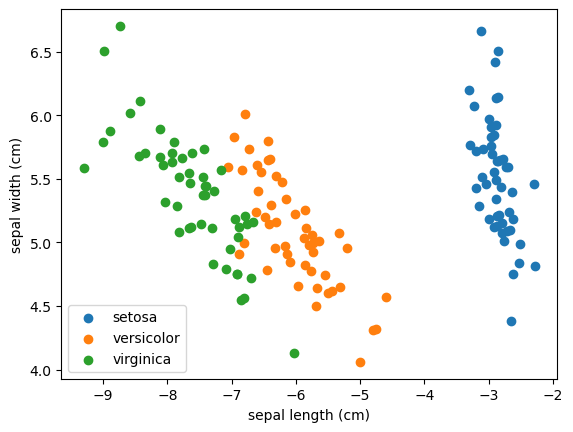

In [124]:
def PCA(x,C,m):
    s, U = np.linalg.eigh(C)
    P = U[:, ::-1][:, 0:m]
    DP = np.dot(P.T, x)
    return P,DP  # Restituisce P (matrice di proiezione)

U,DP=PCA(D,C,2)
get_scatters(DP,L,features,classes)



In [131]:
# Salvataggio del grafico PCA
import os
output_dir = '../images'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(10, 8))
plt.xlabel("First Principal Component", fontsize=12)
plt.ylabel("Second Principal Component", fontsize=12)
plt.title("PCA Projection - All Classes", fontsize=14)

for c in range(len(classes)):
    mask = L==c
    DP_class = DP[:, mask]
    plt.scatter(DP_class[0, :], DP_class[1, :], label=classes[c], alpha=0.6, s=50)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'pca_projection.png'), dpi=150, bbox_inches='tight')
plt.close()

print("PCA projection saved to images/pca_projection.png")

PCA projection saved to images/pca_projection.png


In [125]:
def compute_Sb_Sw(D,L,classes):
    Sw=0
    Sb=0
    N=D.shape[1]
    mu=getCol(getMu(D))
    # Itera sulle classi uniche presenti nei dati, non su range(len(classes))
    for c in np.unique(L):
        mask=L==c
        D0=D[:,mask]
        nc=D0.shape[1]
        mc=getCol(getMu(D0))
        Sb+=nc*((mc-mu)@(mc-mu).T)
        DC=D0-mc
        Sw+=(DC @ DC.T)
    return Sb/N,Sw/N

Sb,Sw=compute_Sb_Sw(D,L,classes)
print(f"La between class covariance matrix è {Sb} \n La within class covariance matrix è{Sw}")




La between class covariance matrix è [[ 0.42141422 -0.13301778  1.101656    0.47519556]
 [-0.13301778  0.07563289 -0.38159733 -0.15288444]
 [ 1.101656   -0.38159733  2.91401867  1.24516   ]
 [ 0.47519556 -0.15288444  1.24516     0.53608889]] 
 La within class covariance matrix è[[0.259708   0.09086667 0.164164   0.03763333]
 [0.09086667 0.11308    0.05413867 0.032056  ]
 [0.164164   0.05413867 0.181484   0.041812  ]
 [0.03763333 0.032056   0.041812   0.041044  ]]


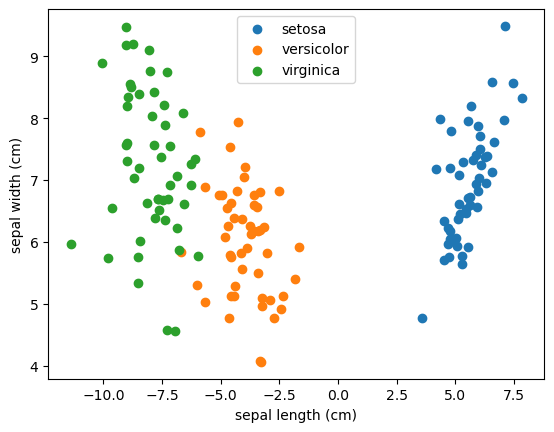

In [126]:
def LDA(D,L,classes,m):
    Sb,Sw=compute_Sb_Sw(D,L,classes)
    s, U = scipy.linalg.eigh(Sb, Sw)
    W = U[:, ::-1][:, 0:m]
    DP=W.T @ D
    return W,DP

W,DP=LDA(D,L,classes,2)
get_scatters(DP,L,features,classes)



In [132]:
# Salvataggio del grafico LDA
plt.figure(figsize=(10, 8))
plt.xlabel("First LDA Component", fontsize=12)
plt.ylabel("Second LDA Component", fontsize=12)
plt.title("LDA Projection - All Classes", fontsize=14)

for c in range(len(classes)):
    mask = L==c
    DP_class = DP[:, mask]
    plt.scatter(DP_class[0, :], DP_class[1, :], label=classes[c], alpha=0.6, s=50)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lda_projection.png'), dpi=150, bbox_inches='tight')
plt.close()

print("LDA projection saved to images/lda_projection.png")

LDA projection saved to images/lda_projection.png


In [127]:
def init_dataset_for_binary_classification():
    iris_dataset=load_iris()
    D_Iris=iris_dataset.data.T
    
    L_Iris=iris_dataset.target
    D=D_Iris[:,L_Iris!=0]
    L=L_Iris[L_Iris!=0]

    
    return D,L

DB,LB=init_dataset_for_binary_classification()

In [128]:
def split_db_2to1(D, L, seed=0):
    nTrain = int(D.shape[1]*2.0/3.0)
    np.random.seed(seed)
    idx = np.random.permutation(D.shape[1])
    idxTrain = idx[0:nTrain]
    idxTest = idx[nTrain:]
    DTR = D[:, idxTrain]
    DVAL = D[:, idxTest]
    LTR = L[idxTrain]
    LVAL = L[idxTest]
    return (DTR, LTR), (DVAL, LVAL)
    # DTR and LTR are model training data and labels
    # DVAL and LVAL are validation data and labels

(DTR, LTR), (DVAL, LVAL) = split_db_2to1(DB, LB)


In [129]:
def LDA_classifier(DTR,LTR,DVAL,LVAL):

    # Identifica le classi uniche presenti nei dati (1 e 2, non 0-1-2)
    unique_classes = np.unique(LTR)
    
    # Controlla l'orientamento: la media di Virginica (2) deve essere > media di Versicolor (1)
    W,DTR_lda = LDA(DTR,LTR,unique_classes,1)
    mean_versicolor = DTR_lda[0, LTR==1].mean()
    mean_virginica = DTR_lda[0, LTR==2].mean()

    # Se l'orientamento è sbagliato, inverti W
    # Vogliamo che la classe Virginica (2) sia sulla destra
    if mean_virginica < mean_versicolor:
        W = -W
        DTR_lda = W.T @ DTR
        mean_versicolor = DTR_lda[0, LTR==1].mean()
        mean_virginica = DTR_lda[0, LTR==2].mean()
    
    threshold = (DTR_lda[0, LTR==1].mean() + DTR_lda[0, LTR==2].mean()) / 2.0 #Projected samples have only 1 dimension
    DVAL_lda=W.T @ DVAL
    PVAL = np.zeros(shape=LVAL.shape, dtype=np.int32)
    PVAL[DVAL_lda[0] >= threshold] = 2
    PVAL[DVAL_lda[0] < threshold] = 1

    print('Threshold:', threshold)
    print('Mean Versicolor (class 1):', mean_versicolor, 'Mean Virginica (class 2):', mean_virginica)
    print('Labels:     ', LVAL)
    print('Predictions:', PVAL)
    print('Number of errors:', (PVAL != LVAL).sum(), '(out of %d samples)' % (LVAL.size))
    print('Error rate: %.1f%%' % ( (PVAL != LVAL).sum() / float(LVAL.size) *100 ))
print("\n------------------------------------------- LDA Classifier -------------------------------------------\n")
LDA_classifier(DTR,LTR,DVAL,LVAL)


------------------------------------------- LDA Classifier -------------------------------------------

Threshold: 4.078616922547409
Mean Versicolor (class 1): 2.1314931222050717 Mean Virginica (class 2): 6.025740722889748
Labels:      [1 2 1 2 1 1 1 2 2 2 1 2 2 2 1 1 2 1 1 2 2 1 2 2 2 1 1 2 1 2 2 2 1 1]
Predictions: [1 2 1 2 1 1 1 2 2 2 2 2 2 2 1 1 2 1 1 2 2 1 2 2 2 1 1 1 1 2 2 2 1 1]
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%


In [133]:
# Visualizzazione e salvataggio degli istogrammi per il classificatore LDA
unique_classes = np.unique(LTR)
W_vis, DTR_lda_vis = LDA(DTR, LTR, unique_classes, 1)
DVAL_lda_vis = W_vis.T @ DVAL

# Correggi l'orientamento
mean_versicolor = DTR_lda_vis[0, LTR==1].mean()
mean_virginica = DTR_lda_vis[0, LTR==2].mean()
if mean_virginica < mean_versicolor:
    W_vis = -W_vis
    DTR_lda_vis = W_vis.T @ DTR
    DVAL_lda_vis = W_vis.T @ DVAL

# Istogramma Training Set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(DTR_lda_vis[0, LTR==1], bins=5, density=True, alpha=0.6, label='Versicolor', color='orange')
ax1.hist(DTR_lda_vis[0, LTR==2], bins=5, density=True, alpha=0.6, label='Virginica', color='green')
ax1.set_xlabel('LDA Projection', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Model Training Set (DTR, LTR)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Istogramma Validation Set
ax2.hist(DVAL_lda_vis[0, LVAL==1], bins=5, density=True, alpha=0.6, label='Versicolor', color='orange')
ax2.hist(DVAL_lda_vis[0, LVAL==2], bins=5, density=True, alpha=0.6, label='Virginica', color='green')
ax2.set_xlabel('LDA Projection', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Validation Set (DVAL, LVAL)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lda_binary_histograms.png'), dpi=150, bbox_inches='tight')
plt.close()

print("LDA binary classification histograms saved to images/lda_binary_histograms.png")

LDA binary classification histograms saved to images/lda_binary_histograms.png


In [130]:
def LDA_with_PCA_classifier(DTR,LTR,DVAL,LVAL,m):
    print(f"\n--- PCA with m={m} dimensions ---")
    
    # Skip if m=0 (no PCA dimensionality)
    if m == 0:
        print("Skipping m=0 (no projection)")
        return
    
    # Applica PCA: proietta i dati di training e validation
    P, DTR_pca = PCA(DTR, getC(DTR), m)
    DVAL_pca = P.T @ DVAL
    
    # Identifica le classi uniche presenti nei dati (1 e 2, non 0-1-2)
    unique_classes = np.unique(LTR)
    
    # Applica LDA sui dati già proiettati da PCA
    W, DTR_lda = LDA(DTR_pca, LTR, unique_classes, 1)
    mean_versicolor = DTR_lda[0, LTR==1].mean()
    mean_virginica = DTR_lda[0, LTR==2].mean()

    # Se l'orientamento è sbagliato, inverti W
    # Vogliamo che la classe Virginica (2) sia sulla destra
    if mean_virginica < mean_versicolor:
        W = -W
        DTR_lda = W.T @ DTR_pca  # Riproietta i dati PCA, non i dati originali
        mean_versicolor = DTR_lda[0, LTR==1].mean()
        mean_virginica = DTR_lda[0, LTR==2].mean()
    
    threshold = (DTR_lda[0, LTR==1].mean() + DTR_lda[0, LTR==2].mean()) / 2.0
    DVAL_lda = W.T @ DVAL_pca  # Proietta i dati validation già trasformati da PCA
    PVAL = np.zeros(shape=LVAL.shape, dtype=np.int32)
    PVAL[DVAL_lda[0] >= threshold] = 2
    PVAL[DVAL_lda[0] < threshold] = 1
    
    print('Threshold:', threshold)
    print('Mean Versicolor (class 1):', mean_versicolor, 'Mean Virginica (class 2):', mean_virginica)
    print('Number of errors:', (PVAL != LVAL).sum(), '(out of %d samples)' % (LVAL.size))
    print('Error rate: %.1f%%' % ( (PVAL != LVAL).sum() / float(LVAL.size) *100 ))

print("\n------------------------------------------- LDA + PCA Classifier -------------------------------------------\n")
for m in range(1, 5):  # m da 1 a 4 (escludendo 0 e 4 secondo le specifiche)
    LDA_with_PCA_classifier(DTR,LTR,DVAL,LVAL,m)



------------------------------------------- LDA + PCA Classifier -------------------------------------------


--- PCA with m=1 dimensions ---
Threshold: 10.885355831051656
Mean Versicolor (class 1): 9.873770045046513 Mean Virginica (class 2): 11.8969416170568
Number of errors: 4 (out of 34 samples)
Error rate: 11.8%

--- PCA with m=2 dimensions ---
Threshold: 5.354430233331145
Mean Versicolor (class 1): 3.5905551415863677 Mean Virginica (class 2): 7.118305325075922
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%

--- PCA with m=3 dimensions ---
Threshold: 4.534675967911298
Mean Versicolor (class 1): 2.745445664200462 Mean Virginica (class 2): 6.323906271622134
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%

--- PCA with m=4 dimensions ---
Threshold: 4.078616922547413
Mean Versicolor (class 1): 2.131493122205076 Mean Virginica (class 2): 6.025740722889751
Number of errors: 2 (out of 34 samples)
Error rate: 5.9%
